In [1]:
import importlib, vp, mcd
importlib.reload(vp);
importlib.reload(mcd);

In [2]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.transforms import Affine2D

def normalize(x, y):
    l = (x ** 2 + y ** 2) ** 0.5
    return x / l, y / l


def label_position(P, i, offset=0.25):
    px, py = P[i - 1]
    cx, cy = P[i]
    nx, ny = P[(i + 1) % len(P)]
    ax, ay = normalize(cy - py, px - cx)
    bx, by = normalize(ny - cy, cx - nx)
    dx, dy = normalize(ax + bx, ay + by)
    return cx + offset * dx, cy + offset * dy


ellipse = Affine2D().scale(2.0, 1.0).transform_path(Path.unit_circle())


def plot_vp(P, o, verts, poly):
    _, ax = plt.subplots(figsize=(2.5, 2.5))
    ax.set_aspect('equal')
    ax.axis('off')

    xs, ys = zip(*P)
    ax.plot(xs + xs[:1], ys + ys[:1], color='black')

    vert_set = set(verts)
    for i, (x, y) in enumerate(P):
        if i == o:
            ax.scatter(x, y, marker=ellipse, s=150, edgecolor='black', facecolor='white', zorder=3)
            ax.scatter(x, y, marker='.', color='black', zorder=3)
        elif i in vert_set:
            ax.scatter(x, y, marker='o', color='black', zorder=3)
        else:
            ax.scatter(x, y, marker='o', edgecolor='black', facecolor='white', zorder=3)

    for i in range(len(P)):
        x, y = label_position(P, i)
        ax.text(x, y, str(i), color='black', ha='center', va='center')

    xs, ys = zip(*poly)
    ax.plot(xs + xs[:1], ys + ys[:1], color='black')
    ax.fill(xs, ys, color='tab:blue', alpha=0.5)

    plt.show()


def plot_mcd(P, diags):
    _, ax = plt.subplots(figsize=(2.5, 2.5))
    ax.set_aspect('equal')
    ax.axis('off')

    xs, ys = zip(*P)
    ax.plot(xs + xs[:1], ys + ys[:1], color='black')

    for i, (x, y) in enumerate(P):
        if i == 0 or vp.clockwise(P[i - 1], P[i], P[(i + 1) % len(P)]):
            ax.scatter(x, y, marker='o', edgecolor='black', facecolor='black', zorder=3)
        else:
            ax.scatter(x, y, marker='o', edgecolor='black', facecolor='white', zorder=3)

    for i in range(len(P)):
        x, y = label_position(P, i)
        ax.text(x, y, str(i), color='black', ha='center', va='center')

    for i, j in diags:
        xs, ys = zip(P[i], P[j])
        ax.plot(xs, ys, color='black')

    plt.show()

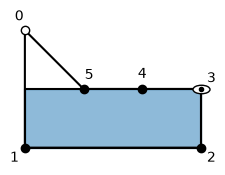

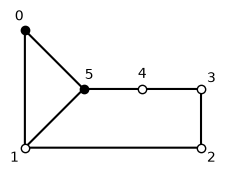

In [3]:
P = [(0, 2), (0, 0), (3, 0), (3, 1), (2, 1), (1, 1)]

o = 3
vis = vp.Visibility(P, o)
plot_vp(P, o, vis.visible_vertices(), vis.visibility_polygon())

dec = mcd.Decomposition(P)
plot_mcd(P, dec.diags())

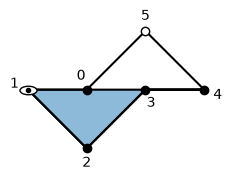

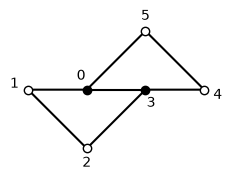

In [4]:
P = [(1, 1), (0, 1), (1, 0), (2, 1), (3, 1), (2, 2)]

o = 1
vis = vp.Visibility(P, o)
plot_vp(P, o, vis.visible_vertices(), vis.visibility_polygon())

dec = mcd.Decomposition(P)
plot_mcd(P, dec.diags())